In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Deep Learning



## Goals

- Demystify Deep Learning
- Be autonomous & prototype easily
- Work on different data types: vector, image, text, time-series, ...

Deep Learning is about practice, _practice_, _**practice**_!

## Plan of the module

- Lecture 1 : Fundamentals of Deep Learning
- Lecture 2 : Optimizers, Loss & Fitting
- Lecture 3 : Convolutional Neural Networks
- Lecture 4 : Recurrent Neural Networks
- Lecture 5 : Natural Language Processing
- Lecture 6 : Transformers
- Lecture 7 : Generative AI and RAG 
- Lecture 8 : GAN and Reinforcement Learning

# Fundamentals of Deep Learning

# 1. Deep Learning is Everywhere 

### Image detection & Image recognition

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/image_recognition.gif" alt="Image detection" style="height:350px;"/>


Autonomous cars, violence detection on public transportation, unlocking phones, person tracking, gesture detection, ...

### Pose estimation

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/pose_estimation.gif" alt="Pose estimation" style="height:350px;"/>

### Pose estimation
<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/pose_cycling.jpg" alt="Natural Language Processing" style="height:350px;"/>

Source: [BioMechanic - Pose Detection with OpenPose](https://www.youtube.com/watch?v=W9xVOl7TT0c)

### Natural Language Processing (In general)

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/nlp.png" alt="Natural Language Processing" style="height:350px;"/>

Retrieval of information from a text input

### Sentiment Analysis

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/sentiment_analysis.gif" alt="Sentiment Analysis" style="height:350px;"/>

Sentiment analysis is part of NLP

### Translation

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/translation.gif" alt="Translation" style="height:200px;"/>

Translation is part of NLP

### Speech to text / Speech Recognition

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/speech_to_text.gif" alt="Speech to text" style="height:300px;"/>

### Detection of multiple sources in sounds / voices / signals

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/source_separation.png" alt="Source Separation" style="height:400px;"/>

### Captioning (Picture to text)

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/captioning.png" alt="Image captioning" style="height:400px;"/>

### Generation of fake pictures, videos, sounds (1/2)

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/which_face_is_real.png" alt="Which face is real" style="height:500px;"/>


www.whichfaceisreal.com

### Generation of fake pictures, videos, sounds (2/2)

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/deepfake.gif" alt="Deep Fake" style="height:400px;"/>

Called DeepFakes

And many many many more! 

⚠️ But don't be lured, many are coooool but not always useful (or leverageable in a business context).

So why is Deep Learning taking the lead on so many subjects? 

# 2. Basic architecture

Let's get some data!

In [ ]:
# Target y (classification task 0/1, e.g. cat/dog)
y = 1

# Input X = one single observation, 4 features (x1, x2, x3, x4)
# (e.g. eyes color, ears_lenghts, ...)
X = [1., -3.1, -7.2, 2.1]

Imagine you have a linear regression with some weights 

In [ ]:
def linreg_1(X):
    return -3 + 2.1*X[0] - 1.2*X[1] + 0.3*X[2] + 1.3*X[3]

out_1 = linreg_1(X)

And you transform it's output 

In [ ]:
def activation(x):
    if x > 0:
        return x
    else:
        return 0

out_1 = activation(out_1)

### Let's call this operation {linear regression, activation} a _NEURON_

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/neuron.png" alt="Neuron of a Neural Network" style="height:180px;"/>


Given an input $X = (x_1, x_2, \ldots, x_n)$, a neuron is the concatenation of:
- A linear combination of the input with the weights $w_k$ plus a bias $b$, that outputs $\sum_{k=1}^n w_k x_k + b$
- A non-linear modification $f$ of that sum

Therefore, the output of a neuron is $output = f(\sum_{k=1}^n w_k x_k + b)$

### Activation Functions (well known examples)

![Example of activation functions](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/activation_functions.png)


❓ Which of these activations did we just code?

Imagine now that you produce another output by:
- applying _another_ linear regression to the same input X
- followed by the _same_ activation function

In [ ]:
def linreg_2(X):
    return -5 - 0.1*X[0] + 1.2*X[1] + 4.9*X[2] - 3.1*X[3]

out_2 = activation(linreg_2(X))

And a third one

In [ ]:
def linreg_3(X):
    return -8 + 0.4*X[0] + 2.6*X[1] +- 2.5*X[2] + 3.8*X[3]

out_3 = activation(linreg_3(X))

### We just wrote a _LAYER_ of neurons

An input $x = (x_1, \ldots, x_n)$ does not pass through a single neuron but through many different neurons. 

<img alt="layer" src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/layer.png" style="height:400px;">


❗ Remark ❗ Each neuron can have a different activation function ($f_1 \neq f_2 ... \neq f_5$) but in practice, each layer only uses one type.

### What if we use the 3 outputs of this layer as input of another layer, again?

In [ ]:
def linreg_next_layer(X):
    return 5.1 + 1.1*X[0] - 4.1*X[1] - 0.7*X[2]

def activation_next_layer(x):
    # sigmoid activation for clasification task!
    return 1. / (1 + np.exp(-x))

def neural_net_predictor(X):

    out_1 = activation(linreg_1(X))
    out_2 = activation(linreg_2(X))
    out_3 = activation(linreg_3(X))

    outs = [out_1, out_2, out_3]

    y_pred = activation_next_layer(linreg_next_layer(outs))

    return y_pred

In [ ]:
# Final prediction
y_pred = neural_net_predictor(X)

print(f' Probability of being a dog: {y_pred}')

 Probability of being a dog: 0.832716044461517


#### 🎉 Congrats! You just built your first (artificial) neural network. 

### So, what is a Neural Network? 

- nothing more than a fancy function $f_\theta$ that computes $\hat{y} = f_{\theta}(x)$ 
- where $\theta$ are the **weights** of all the linear regressions that take place within the neurons

<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/neuralnet_4.png" alt="Neuron of a Neural Network" style="height:400px;"/>

All these neurons and layers make up the **architecture** of the neural network.

❓ **Question:** How many weights are trained in layer 1? In layer 2?

#### _Deep Learning_ simply refers to Neural Networks (that have many layers)


![caption](https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/neuralnet_2.png)

Yes. Deep Learning is nothing more than that. Amazed? Disappointed? Intrigued?

❓ What's the dimension of the prediction?

#### 🤔 Why using activation function at all?

<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/activation_functions.png' width=400 style='margin:auto'>

- To introduce **non-linarities**!
- Without them, our Neural Network would be a simple linear model!

$$A (a_1 \color{blue}{x_1} + a_2 \color{blue}{x_2}) + B (b_1 \color{blue}{x_1} + b_2 \color{blue}{x_2}) = (A a_1 + B b_1) \color{blue}{x_1} + (A a_2 + B b_2) \color{blue}{x_2}$$

### 💻 Let's visualize a Neural Network on [Playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4&seed=0.13983&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false&regularization_hide=true&showTestData_hide=true&stepButton_hide=false&activation_hide=false&problem_hide=false&batchSize_hide=true&dataset_hide=false&resetButton_hide=false&discretize_hide=true&playButton_hide=false&learningRate_hide=true&regularizationRate_hide=true&percTrainData_hide=true&numHiddenLayers_hide=false) 

- Look familiar? Hit the play button ▶️ and see what happens! 


- Can you fit this non-linear problem with only **linear activations** ? 🤔

- Try to fit the other datasets, keeping only one layer

- Try a regression task!

# 3. My first Neural Network in Keras

## 3.1 Keras

* **TensorFlow** is an open-source machine learning framework developed by Google for building and deploying achine learning and deep learning models. 

* **Keras** is an open-source deep learning API that runs on top of Tensorflow, provigin a user friendly interface for building and training neural networks.


<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/keras_and_tf.png" width=400>

**Documentation**

📚 [tensorflow.keras](https://www.tensorflow.org/guide/keras)

📚 [keras](https://keras.io/getting_started/)



🖥️ **Installation**

`pip install tensorflow`

This will also install a compatible version of Keras

**In 🐍 Python to code:**

`from tensorflow.keras import *`

`from keras import *`

* Functionally, both are the same
* The second option has better documentation pop-up support in VS Code.


---

_Defining_ & _Training_ a Neural Network in three steps:

**1. Define the architecture** $f$ of your model that, given an input $X$,it outputs $y_{pred} = f_{\theta_0}(X)$ (Here, the weights $\theta_0$ are random)

```python
from tensorflow.keras import Sequential
model = Sequential()
model.add(...)
```

**2. Define the methods** to estimate the best $\theta$ possible, which means having $y_{pred}$ close to the real output $y$

```python
model.compile(...)
```

**3. Fitting on on data**: Going from $\theta_0$ => $\theta$ based on the data X and y

```python
model.fit(X, y, ...)
```

**Then, you can use it**
```python
y_new = model.predict(X_new)
```  

&nbsp;  
❓ Here is the perfect time to ask questions.

🤔 Ok, but what are we hiding in the `...`?

## 3.2 Sequential architecture : `model.add(...)`

**It corresponds to the definition of the architecture.**



<img src="https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/neuralnet_0.png" alt="Neuron of a Neural Network" style="height:300px;"/>

Each layer has to be added with the `model.add(...)` 

💻 Let's code it

In [ ]:
from keras import Sequential, layers

# Basically, it will look like a sequence of layers
model = Sequential()

# First layer: 10 neurons and ReLU as the activation function
model.add(layers.Dense(10, activation='relu'))

# Disclaimer: The standard layers are called Fully Connected (Dense in Keras)

In [ ]:
# You can go for two fully connected layers
model = Sequential()
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(20, activation='tanh'))

In [ ]:
# You can also go for many, many, many more ...

model = Sequential()
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(20, activation='tanh'))
model.add(layers.Dense(10, activation='linear'))
model.add(layers.Dense(100, activation='sigmoid'))
model.add(layers.Dense(40, activation='softmax'))
model.add(layers.Dense(10, activation='tanh'))
model.add(layers.Dense(3, activation='relu'))
model.add(layers.Dense(9, activation='tanh'))
model.add(layers.Dense(8900, activation='relu'))
model.add(layers.Dense(1000, activation='tanh'))

### Decision Rules

🤔 Ok... but how am I supposed to choose? 

- Most decisions rely on practice
- Nonetheless, some are directly related to the problem/task you are tackling!

**Rule 1: tell the model the shape of your inputs**

In [5]:
from keras import Sequential, Input

model = Sequential()

# Imagine each observation has 4 features (x1, x2, x3, x4)
model.add(Input(shape=(4,))) # Shape has to be a tuple

* The Input's shape directly impacts the **number of weights** in the first layer.
* Without specifying it, the model would infer the size the first time it sees a training batch.
* It's better to specify it upfront: Keras can already build the model and allocate memory.

**Rule 2: The last layer is ditacted by the task**

&nbsp;

**REGRESSION** TASKS REQUIRE **LINEAR** ACTIVATION FUNCTIONS

In [ ]:
### size 1 (predict one value):
model.add(layers.Dense(1, activation='linear'))

# OR

### size 13 (y_pred.shape=(13,))
model.add(layers.Dense(13, activation='linear'))

**CLASSIFICATION** TASKS REQUIRES **SOFTMAX**/SIGMOID

In [ ]:
### 2 classes (binary)
model.add(layers.Dense(1, activation='sigmoid'))

# OR

### 8 classes (y_pred.shape=(8,))
model.add(layers.Dense(8, activation='softmax'))

**Softmax** turns numbers into **probabilities** that sums to 1:


<img src='https://wagon-public-datasets.s3.amazonaws.com/data-science-images/lectures/deep-learning/01/softmax.png' width=500>

☝️ Softmax (2 classes) = Sigmoid

Full Model Recap

In [ ]:
### Regression of size 1
model = Sequential()
model.add(Input(shape=(100,)))
model.add(layers.Dense(10, activation='relu'))
#model.add(...)
model.add(layers.Dense(1, activation='linear'))


### Regression of size 13
model = Sequential()
model.add(Input(shape=(100,)))
model.add(layers.Dense(10, activation='relu'))
#model.add(...)
model.add(layers.Dense(13, activation='linear'))


### Classification with 2 classes
model = Sequential()
model.add(Input(shape=(100,)))
model.add(layers.Dense(10, activation='relu'))
#model.add(...)
model.add(layers.Dense(1, activation='sigmoid'))


### Classification with 8 classes
model = Sequential()
model.add(Input(shape=(100,)))
model.add(layers.Dense(10, activation='relu'))
#model.add(...)
model.add(layers.Dense(8, activation='softmax'))

❓ Which task was our first example? Which activation did we use?

#### [Playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.13983&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false&regularization_hide=true&showTestData_hide=false&stepButton_hide=true&activation_hide=true&problem_hide=false&batchSize_hide=true&dataset_hide=false&resetButton_hide=false&discretize_hide=true&playButton_hide=false&learningRate_hide=true&regularizationRate_hide=true&percTrainData_hide=true&numHiddenLayers_hide=false) challenge

💻 Build a model with three hidden layers where the first has 5 neurons, the second has 4 neurons and the third has 3 neurons.

Then, run it on any dataset.

In practice, apart from the input size and the last layer, you have to choose:
- the number of neurons
- the number of layers
- the activation functions

**But how?**

=> This is the experimental part. This is where the mastery of Deep Learning comes in.

Practice has shown us that some decisions are best to start with as they usually work better. 

💡 For instance, (almost) always **start** with the `relu` activation function - if it is not the last layer!

### Counting number of parameters with `model.summary()`

In [7]:
# Small exercice: how many parameters in this simple regression task:
from keras import layers

model = Sequential()
model.add(Input(shape=(4,)))
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(1, activation='linear'))

In [8]:
10*4 + 10 + 10 + 1

61

In [9]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            50 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Small exercice: how many parameters in this model:

model = Sequential()
model.add(layers.Dense(64, input_shape=(784,), activation='relu'))
model.add(layers.Dense(64, activation='tanh'))
model.add(layers.Dense(10, activation='softmax'))

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Answer : Use the summary() function to keep track of what you are doing

model = Sequential()
model.add(layers.Dense(64, input_shape=(784,), activation='relu'))
model.add(layers.Dense(64, activation='tanh'))
model.add(layers.Dense(10, activation='softmax'))

model.summary()
print("manual calculation = ", (64*784 + 64) + (64*64 + 64) + (10*64 + 10))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

manual calculation =  55050


# 4. Training: loss & optimization procedure

`model.compile(...)`  
`model.fit(...)`

👉 Focus of lecture 2

## 4.1 Compiling

```python
model.compile(loss='mse', optimizer='adam')
```

- The loss is the way you compare $y_{true}$ to $y_{pred}$
- The optimizer is the way you update $\theta$ over the iterations to get closer to $y_{true}$ (called "solver" in sklearn)

## 4.2 Fitting

```python
model.fit(X, y, batch_size=32, epochs=10)
```

It tries to find the $\theta$ that minimizes the loss function.

The learning phase is **iterative** and **stochastic** (remember SGD?).

The intuition is that you give a subset of data, and the algorithm updates the parameters $\theta$: 

- `batch_size` is the size of the subset given to the neural network to update the parameters $\theta$ 
- The entire dataset is split into different batches 
- Once the algorithm has seen all the data, it counts as one `epoch`

[Check out the docs](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit) to see all the arguments of `model.fit()`.

# 5 Full Example: Face recognition

In [ ]:
# Load data
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=200, resize=0.25)

# 766 images of 31 * 23 pixel black & white
print(faces.images.shape)

(766, 31, 23)


In [ ]:
# 2 different target classes
np.unique(faces.target)

array([0, 1])

Let's visualize some faces:

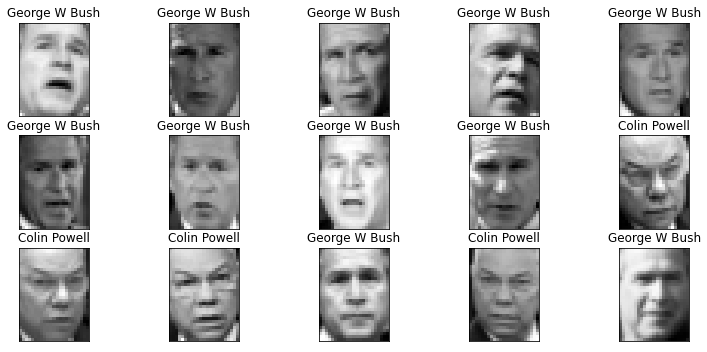

In [ ]:
fig = plt.figure(figsize=(13,10))
for i in range(15):
    plt.subplot(5, 5, i + 1)
    plt.title(faces.target_names[faces.target[i]], size=12)
    plt.imshow(faces.images[i], cmap=plt.cm.gray)
    plt.xticks(()); plt.yticks(())

#### Minimal preprocessing

In [ ]:
# Flatten our 766 images
X = faces.images.reshape(766, 31*23)
X.shape

(766, 713)

In [ ]:
y = faces.target
y.shape

(766,)

In [ ]:
# Train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=3)

In [ ]:
# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

#### Simple model with 1 hidden layer

In [12]:
from keras import Sequential
from keras import layers

# Model definition
model = Sequential()
model.add(Input(shape=(713,)))
model.add(layers.Dense(20, activation='relu'))
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 20)             │        14,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,501 (56.64 KB)

 Trainable params: 14,501 (56.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics = 'accuracy')

model.fit(X_train, y_train, batch_size=16, epochs=20)

#### Evaluate performance

In [ ]:
model.evaluate(scaler.transform(X_test), y_test)
# returns [loss, metrics]

6/6 [==============================] - 0s 997us/step - loss: 0.3128 - accuracy: 0.9323


[0.3128136992454529, 0.9322916865348816]

&nbsp;

🤔 Is it good? What's our baseline?

In [ ]:
pd.Series(y).value_counts()

1    530
0    236
dtype: int64

In [ ]:
# Baseline score
530 / (530+236)

0.6919060052219321

#### Let's check our predictions!

In [ ]:
# Predicted probabilities for the first ten pictures
model.predict(scaler.transform(X_test))[:10]

array([[9.9999869e-01],
       [6.2334865e-02],
       [9.9971330e-01],
       [1.1190176e-03],
       [1.5191197e-02],
       [9.9749875e-01],
       [1.3614774e-02],
       [9.9999332e-01],
       [3.0396730e-05],
       [9.9996662e-01],
       [8.4340572e-01],
       [9.9999964e-01],
       [7.1979084e-05],
       [1.0000000e+00],
       [3.5537034e-02],
       [9.9998999e-01],
       [9.9999958e-01],
       [9.9982762e-01],
       [9.9999946e-01],
       [9.9974364e-01],
       [9.9947500e-01],
       [1.0000000e+00],
       [9.9999762e-01],
       [9.2007339e-02],
       [9.9999273e-01],
       [9.9994254e-01],
       [9.9977076e-01],
       [4.0464237e-01],
       [9.7743982e-01],
       [9.9997973e-01],
       [1.8348694e-03],
       [9.9967110e-01],
       [1.0000000e+00],
       [7.8940392e-04],
       [9.9869871e-01],
       [1.3730466e-02],
       [9.9997890e-01],
       [9.9812841e-01],
       [1.6114116e-04],
       [9.1735780e-01],
       [4.8156780e-05],
       [3.446340

# Conclusion & Intuition

### All in all, Deep Learning is nothing more than 

- multiple linear regressions stacked together
- non-linear functions: the activation functions

### Why does it work?

#### A) Mathematically speaking
Dense networks are **universal approximations**: with just one hidden layer, they can approximate any continuous function with arbitrary precision.
<img src="https://miro.medium.com/max/2400/0*7zfzusUQQ0JKudjl" width=500>

☝️ This does not guarantee that you can easily **find** these optimal parameters of your model! 

It may require extremely large sample size or computing power.

You will see that dense networks are not always the most appropriate architecture (in particular for images, text...).

#### B) Intuitively speaking

❗️ Contrary to other ML algorithms, Neural Networks are very hard to understand intuitively.

Therefore, the goal is not to understand **why** it works to start with. 

The goal is to learn **what** makes it work.

🚀 Let's do that by practicing.

### 💡 Pro tips:

- First layer needs the size of your input
- Last layer's number of neurons equals the output dimension
- Last layer's activation is Linear (regression) or softmax/sigmoid (classification)
- Almost always **start** with the `relu` activation function - if it is not the last layer

### Bibliography

- [How many layers / neurons do I need?](https://towardsdatascience.com/beginners-ask-how-many-hidden-layers-neurons-to-use-in-artificial-neural-networks-51466afa0d3e)
- [Activation function explained by Louis Bouchard](https://www.louisbouchard.ai/densenet-explained/)